# Car Dataset Exploratory Data Analysis

## Objectives:

- Understand dataset structure
- Detect data quality issues
- Clean the data
- Analyze relationships
- Generate insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("data/car_price_dataset.csv")

## Information:

In [3]:
pd.set_option('display.max_columns', None)
df.head(20)

,Brand,Model,Year,CarAge,Condition,Mileage(km),EngineSize(L),FuelType,Horsepower,Torque,Transmission,DriveType,BodyType,Doors,Seats,Color,Interior,Options,City,AccidentHistory,Insurance,RegistrationStatus,FuelEfficiency(L/100km),PricePerKm,Price($)
0,Porsche,Panamera,2008,17,Used,256395,3.3,Gasoline,513,395,Manual,AWD,Sedan,4,4,White,Cloth,"Navigation, Cruise Control, Heated Seats, Blue...",Tehran,No,Valid,Incomplete,11.96,0.05,13884
1,Audi,A6,2023,2,Used,20433,2.2,Diesel,302,270,Manual,FWD,Sedan,4,5,Black,Cloth,"Parking Sensors, Cruise Control, Touchscreen",Berlin,Yes,Expired,Incomplete,8.74,1.90,38888
2,BMW,X5,2022,3,Used,52328,3.2,Gasoline,400,388,Automatic,AWD,SUV,5,7,Gray,Leather,"Touchscreen, Bluetooth, Cruise Control, Naviga...",Tokyo,Yes,Valid,Complete,15.68,0.63,33074
3,Hyundai,Tucson,2019,6,Used,91878,1.6,Hybrid,187,219,Automatic,FWD,SUV,5,5,Silver,Cloth,"Sunroof, Rear Camera, Bluetooth, Parking Senso...",Delhi,No,Expired,Complete,9.45,0.14,12966
4,Fiat,500,2012,13,Damaged,192331,1.1,Gasoline,90,112,Automatic,FWD,Hatchback,3,4,Red,Leather,"Heated Seats, Touchscreen",Delhi,No,Valid,Complete,7.16,0.01,2670
5,Porsche,911 Carrera,2018,7,Used,110968,3.3,Gasoline,565,392,Automatic,AWD,Coupe,2,2,White,Cloth,Sunroof,Paris,No,Expired,Incomplete,12.69,0.43,47830
6,Mercedes-Benz,S-Class,2019,6,Used,82607,5.8,Hybrid,509,750,Manual,RWD,Sedan,4,5,Silver,Cloth,"Navigation, Parking Sensors, Touchscreen",Los Angeles,Yes,Expired,Complete,17.83,0.62,51189
7,Porsche,Panamera,2014,11,Used,163074,3.5,Gasoline,513,428,Manual,RWD,Sedan,4,4,Red,Cloth,"Bluetooth, Touchscreen, Cruise Control, Heated...",Tokyo,No,Valid,Complete,13.06,0.17,27296
8,Audi,Q7,2007,18,Used,274471,2.0,Gasoline,315,277,Automatic,AWD,SUV,5,7,Red,Leather,"Touchscreen, Bluetooth",Tokyo,Yes,Expired,Incomplete,10.38,0.02,5389
9,Ford,Mustang,2019,6,Used,95498,4.6,Gasoline,364,588,Manual,RWD,Coupe,2,2,Red,Cloth,"Touchscreen, Cruise Control, Navigation, Bluet...",Berlin,Yes,Valid,Complete,14.90,0.11,10704


In [4]:
df.shape

(50000, 25)

In [5]:
df.dtypes

Brand                          str
Model                          str
Year                         int64
CarAge                       int64
Condition                      str
Mileage(km)                  int64
EngineSize(L)              float64
FuelType                       str
Horsepower                   int64
Torque                       int64
Transmission                   str
DriveType                      str
BodyType                       str
Doors                        int64
Seats                        int64
Color                          str
Interior                       str
Options                        str
City                           str
AccidentHistory                str
Insurance                      str
RegistrationStatus             str
FuelEfficiency(L/100km)    float64
PricePerKm                 float64
Price($)                     int64
dtype: object

In [6]:
df.isnull().sum()

Brand                         0
Model                         0
Year                          0
CarAge                        0
Condition                     0
Mileage(km)                   0
EngineSize(L)                 0
FuelType                      0
Horsepower                    0
Torque                        0
Transmission                  0
DriveType                     0
BodyType                      0
Doors                         0
Seats                         0
Color                         0
Interior                      0
Options                       0
City                          0
AccidentHistory               0
Insurance                     0
RegistrationStatus            0
FuelEfficiency(L/100km)       0
PricePerKm                 2459
Price($)                      0
dtype: int64

In [7]:
missing=df.isnull().mean()*100
print(missing.sort_values(ascending=False))

PricePerKm                 4.918
Model                      0.000
Year                       0.000
CarAge                     0.000
Condition                  0.000
Mileage(km)                0.000
EngineSize(L)              0.000
FuelType                   0.000
Brand                      0.000
Horsepower                 0.000
Torque                     0.000
DriveType                  0.000
Transmission               0.000
Doors                      0.000
Seats                      0.000
Color                      0.000
BodyType                   0.000
Interior                   0.000
Options                    0.000
AccidentHistory            0.000
City                       0.000
Insurance                  0.000
RegistrationStatus         0.000
FuelEfficiency(L/100km)    0.000
Price($)                   0.000
dtype: float64


## Cleaning:

### Making all the columns lower case and removing extra spaces

In [8]:
df.columns=(df.columns.str.lower().str.strip())

### Renaming of the columns

In [9]:
df = df.rename(columns={"enginesize(l)": "enginesize"})
df = df.rename(columns={"fuelefficiency(l/100km)": "fuelefficiency"})
df = df.rename(columns={"price($)": "price"})
df = df.rename(columns={"mileage(km)": "mileage"})

### Defining Scope
- We are removing rows with missing priceperkm because we only want to deal with old cars.
- Since out of 2,459 missing priceperkm values, 2,454 belong to New cars, and only 5 belong to 
- Used cars, that is why we are dropping these rows, which will remove all New cars (out of scope)
- We also removed the rows having fuel type as electric, since we only wanted to analyze cars running on fuels.
- This led to shrinking our 50000 rows into 42708 rows.

In [10]:
df['condition'].value_counts()

condition
Used       42767
Damaged     4779
New         2454
Name: count, dtype: int64

In [11]:
df=df.dropna(subset="priceperkm")

In [12]:
df['condition'].value_counts()

condition
Used       42762
Damaged     4779
Name: count, dtype: int64

In [13]:
df["fueltype"].value_counts()

fueltype
Gasoline    30799
Hybrid       9875
Electric     4833
Diesel       2034
Name: count, dtype: int64

In [14]:
df = df[df["fueltype"] != "Electric"]

In [15]:
df["fueltype"].value_counts()

fueltype
Gasoline    30799
Hybrid       9875
Diesel       2034
Name: count, dtype: int64

In [16]:
df.shape

(42708, 25)

### Mean, Median and other important calculations

In [17]:
df.describe()

,year,carage,mileage,enginesize,horsepower,torque,doors,seats,fuelefficiency,priceperkm,price
count,42708.000000,42708.000000,42708.000000,42708.000000,42708.000000,42708.000000,42708.000000,42708.000000,42708.000000,42708.000000,42708.000000
mean,2014.483680,10.516320,157748.894985,2.366863,260.255971,307.219865,4.111478,4.682191,10.400359,0.297851,14007.066006
std,5.768721,5.768721,86676.836561,0.935592,126.893769,125.159146,0.993767,1.102019,2.738619,0.837763,14642.742710
min,2005.000000,1.000000,1081.000000,0.900000,65.000000,16.000000,2.000000,2.000000,5.000000,0.000000,1249.000000
25%,2010.000000,6.000000,82781.250000,1.700000,174.000000,217.000000,4.000000,5.000000,8.270000,0.020000,4568.000000
50%,2014.000000,11.000000,158526.000000,2.200000,226.000000,290.000000,4.000000,5.000000,10.180000,0.060000,9135.000000
75%,2019.000000,15.000000,232639.750000,2.900000,364.000000,385.000000,5.000000,5.000000,12.210000,0.210000,17492.250000
max,2024.000000,20.000000,320262.000000,6.000000,581.000000,850.000000,5.000000,7.000000,21.180000,34.560000,117598.000000


### Using mapping dictionary to change simple binary values into booleans

In [18]:
bool_map={'Yes':True,'No':False}
bool_map2={'Valid':True,'Expired':False}
bool_map3={'Incomplete':True,'Complete':False}
df["accidenthistory"]=df["accidenthistory"].map(bool_map)
df["insurance"]=df["insurance"].map(bool_map2)
df["registrationstatus"]=df["registrationstatus"].map(bool_map3)

## Final Cleansed Data

In [19]:
df.head()

,brand,model,year,carage,condition,mileage,enginesize,fueltype,horsepower,torque,transmission,drivetype,bodytype,doors,seats,color,interior,options,city,accidenthistory,insurance,registrationstatus,fuelefficiency,priceperkm,price
0,Porsche,Panamera,2008,17,Used,256395,3.3,Gasoline,513,395,Manual,AWD,Sedan,4,4,White,Cloth,"Navigation, Cruise Control, Heated Seats, Blue...",Tehran,False,True,True,11.96,0.05,13884
1,Audi,A6,2023,2,Used,20433,2.2,Diesel,302,270,Manual,FWD,Sedan,4,5,Black,Cloth,"Parking Sensors, Cruise Control, Touchscreen",Berlin,True,False,True,8.74,1.90,38888
2,BMW,X5,2022,3,Used,52328,3.2,Gasoline,400,388,Automatic,AWD,SUV,5,7,Gray,Leather,"Touchscreen, Bluetooth, Cruise Control, Naviga...",Tokyo,True,True,False,15.68,0.63,33074
3,Hyundai,Tucson,2019,6,Used,91878,1.6,Hybrid,187,219,Automatic,FWD,SUV,5,5,Silver,Cloth,"Sunroof, Rear Camera, Bluetooth, Parking Senso...",Delhi,False,False,False,9.45,0.14,12966
4,Fiat,500,2012,13,Damaged,192331,1.1,Gasoline,90,112,Automatic,FWD,Hatchback,3,4,Red,Leather,"Heated Seats, Touchscreen",Delhi,False,True,False,7.16,0.01,2670


In [20]:
df.shape

(42708, 25)

### Note: we left options column untouched but we may clean it in future

## Univariate Analysis:

## Price
- We can clearly see that the maximum value is far greater than the values in the middle, while the minimum value is closer to the middle.
- So these values suggest that some expensive cars are making the average car price appear to be more expensive.
- That is why, instead of taking the mean as an average for price, we will take it as a median since it's the middle of the data.
- The mean shows there are outliers, and the graph is also right-skewed, showing expensive cars as outliers.

In [21]:
df['price'].describe()

count     42708.000000
mean      14007.066006
std       14642.742710
min        1249.000000
25%        4568.000000
50%        9135.000000
75%       17492.250000
max      117598.000000
Name: price, dtype: float64

In [22]:
sns.set_theme(style="darkgrid")
sns.set_palette("coolwarm")

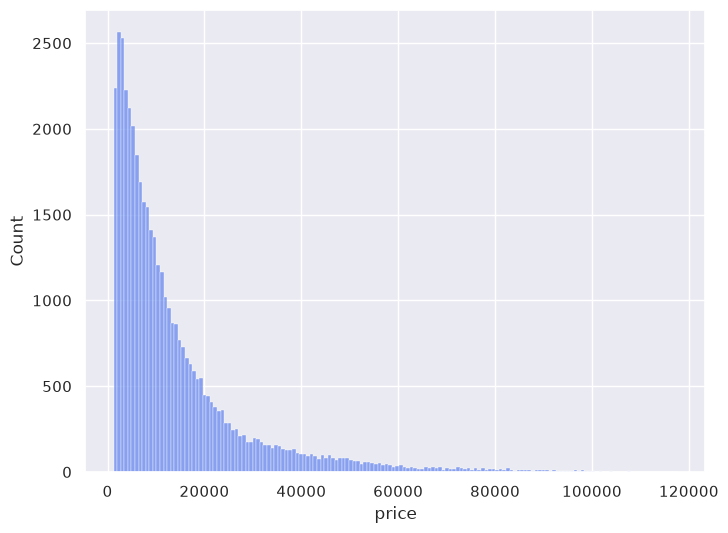

In [23]:
plt.figure(figsize=(8,6))
sns.histplot(df["price"]);

## Fuel Efficiency:
- The average fuel efficiency of a car is 10.
- The maximum fuel efficiency is 21, while the lowest is 5

In [24]:
df['fuelefficiency'].describe()

count    42708.000000
mean        10.400359
std          2.738619
min          5.000000
25%          8.270000
50%         10.180000
75%         12.210000
max         21.180000
Name: fuelefficiency, dtype: float64

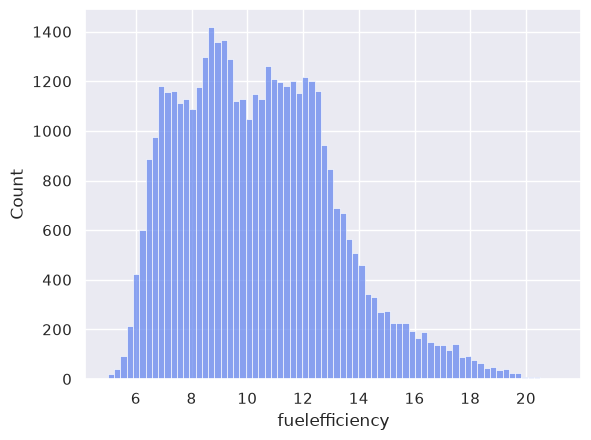

In [25]:
sns.histplot(df["fuelefficiency"]);

## Horsepower
- The maximum horsepower is 581, while the lowest is 64
- There is no average horsepower because it varies according to the body type
- We see multimodal distribution in our visualization, which further shows there are peaks in clusters, indicating that there is no single average

In [26]:
df["horsepower"].describe()

count    42708.000000
mean       260.255971
std        126.893769
min         65.000000
25%        174.000000
50%        226.000000
75%        364.000000
max        581.000000
Name: horsepower, dtype: float64

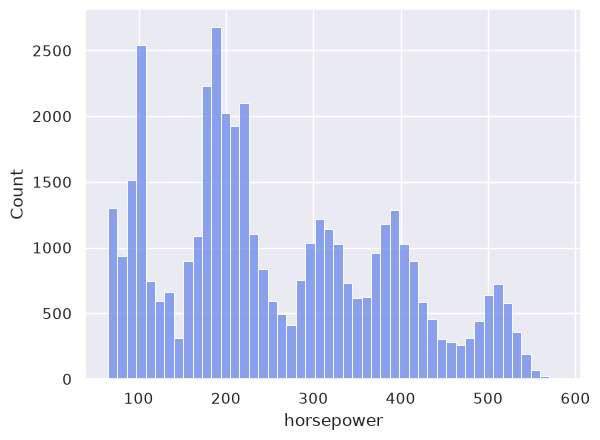

In [27]:
sns.histplot(df["horsepower"]);

In [28]:
df.groupby("bodytype")["horsepower"].mean().sort_values()

bodytype
Hatchback      117.789959
Convertible    181.000000
SUV            265.347239
Sedan          304.737362
Pickup         386.473146
Coupe          402.576321
Name: horsepower, dtype: float64

## Engine Size

- Skipped as a separate deep univariate writeup because enginesize is also driven largely by bodytype (same groupby pattern as horsepower)
- Hatchback lowest at 1.30L to Pickup highest at 3.82L.
- However, unlike horsepower, mean (2.37) and median (2.20) here are close, suggesting the spread is less skewed despite still being multimodal
- bodytype explains the clusters, but doesn't pull the average as far off-center as it did for horsepower.

In [29]:
df["enginesize"].describe()

count    42708.000000
mean         2.366863
std          0.935592
min          0.900000
25%          1.700000
50%          2.200000
75%          2.900000
max          6.000000
Name: enginesize, dtype: float64

In [30]:
df.groupby("bodytype")["enginesize"].mean().sort_values()

bodytype
Hatchback      1.301647
Convertible    2.000000
SUV            2.543124
Sedan          2.660963
Coupe          3.156475
Pickup         3.816240
Name: enginesize, dtype: float64

## Mileage in km
- The maximum mileage by a car is 320262, and the minimum mileage is 1081
- The average mileage from the data appears to be 157748 
- There is no other feature disturbing the car mileage, as it purely depends on how much it is being used

In [31]:
df["mileage"].describe()

count     42708.000000
mean     157748.894985
std       86676.836561
min        1081.000000
25%       82781.250000
50%      158526.000000
75%      232639.750000
max      320262.000000
Name: mileage, dtype: float64

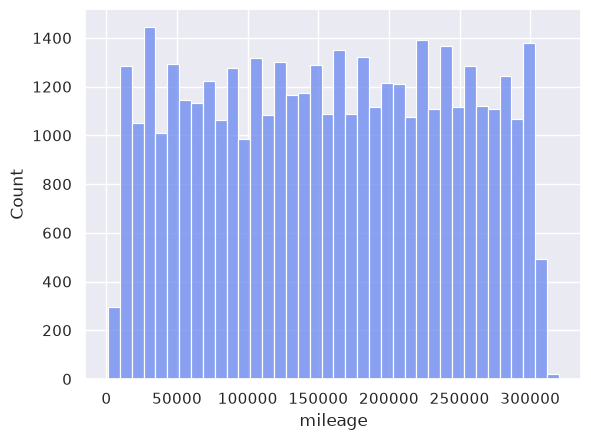

In [32]:
sns.histplot(df["mileage"]);

## Cars Age
- The max age is 20 while min is 1
- The average is 10

In [33]:
df["carage"].describe()

count    42708.000000
mean        10.516320
std          5.768721
min          1.000000
25%          6.000000
50%         11.000000
75%         15.000000
max         20.000000
Name: carage, dtype: float64

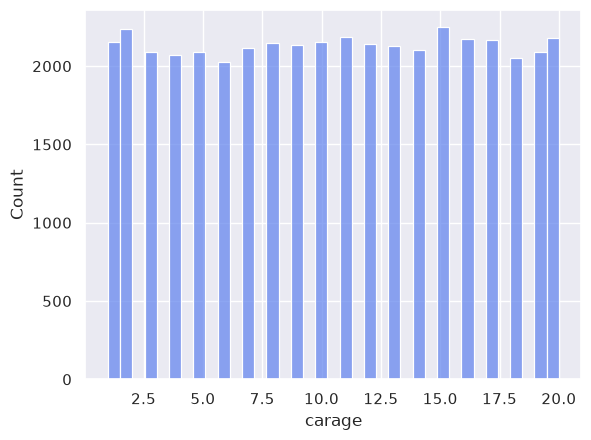

In [34]:
sns.histplot(df["carage"]);

## Brand
- There are about 16 unique brands in 42708 cars
- The most frequently occurring brand is Toyota, which has occurred about 5443 times
- The least occurring brands are Fiat and Peugeot, with Fiat being the lowest one
- Also, the graph shows unevenness where some brands (Toyota, Audi, BMW, Mercedes-Benz) occur more often, while several brands (Fiat, Peugeot, Dacia, 
  Chevrolt) appears far less often.
  

In [35]:
df["brand"].describe()

count      42708
unique        16
top       Toyota
freq        5443
Name: brand, dtype: object

In [36]:
df["brand"].value_counts()

brand
Toyota           5443
Audi             4421
Mercedes-Benz    4411
BMW              4096
Mazda            3375
Porsche          3313
Hyundai          3196
Ford             2989
Volkswagen       2305
Kia              2220
Honda            2185
Chevrolet        1127
Renault          1123
Dacia            1068
Peugeot           723
Fiat              713
Name: count, dtype: int64

<Axes: xlabel='brand', ylabel='Count'>

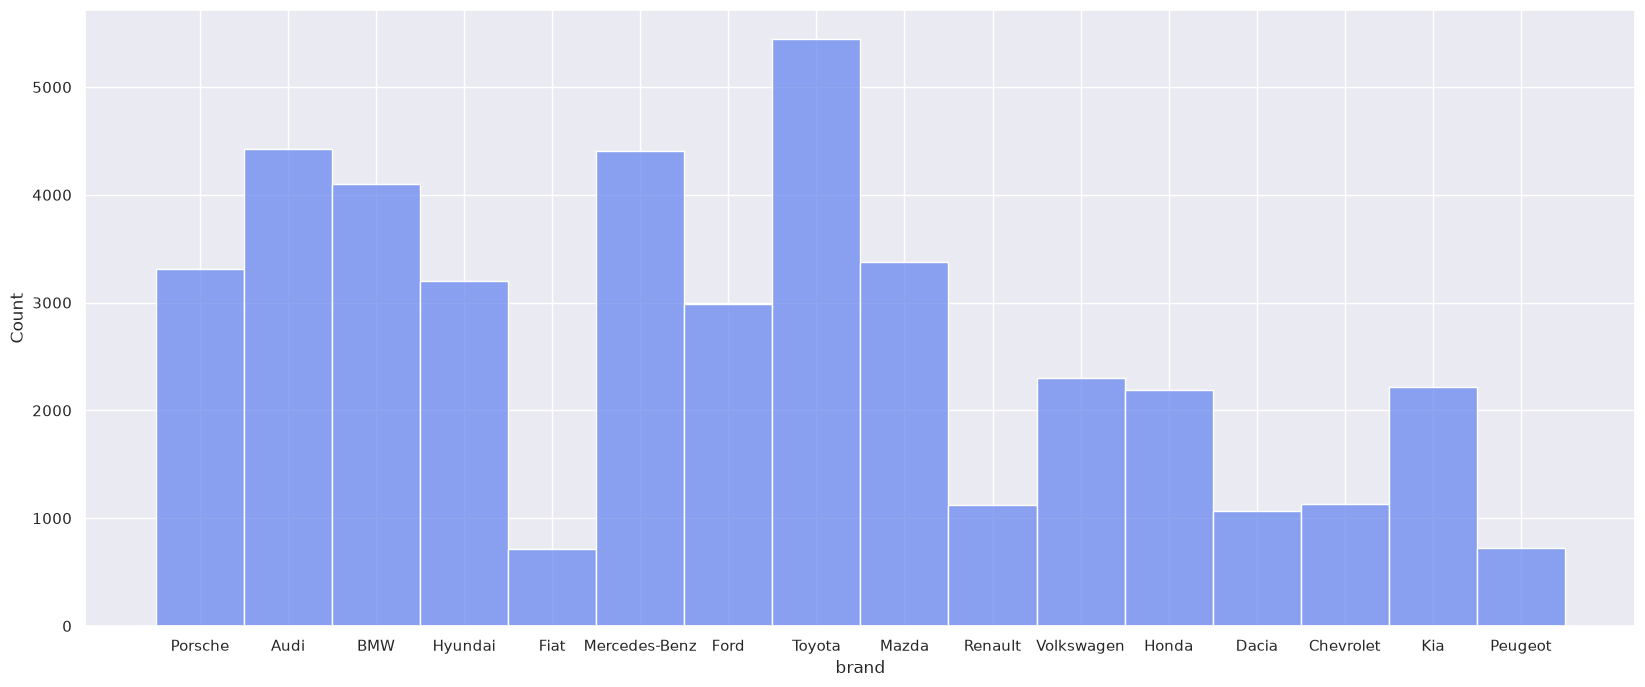

In [37]:
plt.figure(figsize=(20,8))
sns.histplot(df["brand"])

## Fuel Type
- Most of the cars mentioned are running on Gasoline up to 30799
- Hybrid being 9875
- And Diesel being 2034
- Distribution is heavily skewed toward Gasoline — it makes up about 72% 
  of the dataset, while Diesel is under 5%
- As with the brand, comparisons involving Diesel later should be treated 
  With some caution, given the small sample size

In [38]:
df["fueltype"].descrobe()

AttributeError: 'Series' object has no attribute 'descrobe'

In [ ]:
df["fueltype"].value_counts()

In [ ]:
sns.histplot(df["fueltype"])

In [ ]:
import os
print(os.getcwd())